In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import seaborn as sns

In [2]:
df = pd.read_csv('Bus_Breakdown_and_Delays_20260429.csv', low_memory=False)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1277681 entries, 0 to 1277680
Data columns (total 21 columns):
 #   Column                           Non-Null Count    Dtype 
---  ------                           --------------    ----- 
 0   School_Year                      1277680 non-null  object
 1   Busbreakdown_ID                  1277681 non-null  int64 
 2   Run_Type                         1277652 non-null  object
 3   Bus_No                           1277621 non-null  object
 4   Route_Number                     1277546 non-null  object
 5   Reason                           1133377 non-null  object
 6   Schools_Serviced                 1274052 non-null  object
 7   Occurred_On                      1277680 non-null  object
 8   Created_On                       1277680 non-null  object
 9   Boro                             1253604 non-null  object
 10  Bus_Company_Name                 1274189 non-null  object
 11  How_Long_Delayed                 1098910 non-null  object
 12  

In [4]:
df.head(10)

,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,How_Long_Delayed,Number_Of_Students_On_The_Bus,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK
0,2015-2016,1272996,Special Ed AM Run,2256,K355,Won`t Start,15879,06/03/2016 06:03:00 AM,06/03/2016 06:05:00 AM,Brooklyn,...,NaN,0,Yes,Yes,Yes,06/03/2016 06:05:00 AM,NaN,06/03/2016 06:05:05 AM,Breakdown,School-Age
1,2016-2017,1313907,Special Ed AM Run,4481,K002,Won`t Start,22001,01/10/2017 05:55:00 AM,01/10/2017 05:57:00 AM,Brooklyn,...,30min,0,Yes,Yes,No,01/10/2017 05:57:00 AM,NaN,01/10/2017 05:57:42 AM,Running Late,School-Age
2,2015-2016,1267391,Special Ed AM Run,GT2114,Y925,Won`t Start,11012,05/11/2016 05:50:00 AM,05/11/2016 05:59:00 AM,Bronx,...,30 MIN,0,Yes,Yes,Yes,05/11/2016 05:59:00 AM,NaN,05/11/2016 05:59:42 AM,Running Late,School-Age
3,2016-2017,1312240,General Ed AM Run,2436,K1546,Other,15032,01/05/2017 06:00:00 AM,01/05/2017 06:05:00 AM,Brooklyn,...,20 MINS,0,No,No,No,01/05/2017 06:05:00 AM,NaN,01/05/2017 06:05:48 AM,Running Late,School-Age
4,2016-2017,1312351,Special Ed AM Run,5814D,X441,Mechanical Problem,11002,01/05/2017 06:45:00 AM,01/05/2017 06:54:00 AM,Bronx,...,NaN,0,Yes,Yes,No,01/05/2017 06:54:00 AM,NaN,01/05/2017 10:50:02 AM,Breakdown,School-Age
5,2016-2017,1320379,Special Ed PM Run,8802D,X565,Flat Tire,11458,02/01/2017 02:17:00 PM,02/01/2017 02:24:00 PM,Bronx,...,NaN,0,Yes,No,No,02/01/2017 02:24:00 PM,NaN,02/01/2017 02:24:04 PM,Breakdown,School-Age
6,2016-2017,1329633,General Ed AM Run,2320,X2355,Mechanical Problem,11006,03/15/2017 05:54:00 AM,03/15/2017 05:59:00 AM,Bronx,...,NaN,0,Yes,No,No,03/15/2017 05:59:00 AM,NaN,03/15/2017 05:59:39 AM,Breakdown,School-Age
7,2016-2017,1339561,Pre-K/EI,AA1,AA2,Flat Tire,S223,04/12/2017 02:00:00 PM,04/12/2017 02:14:00 PM,Queens,...,NaN,4,No,No,No,04/12/2017 02:14:00 PM,NaN,04/12/2017 02:14:14 PM,Breakdown,Pre-K
8,2016-2017,1321074,Special Ed AM Run,GT 1479,Y749,Mechanical Problem,11688,02/06/2017 06:01:00 AM,02/06/2017 06:02:00 AM,NaN,...,15 MINS,0,No,Yes,No,02/06/2017 06:02:00 AM,NaN,02/06/2017 06:02:51 AM,Running Late,School-Age
9,2016-2017,1344219,General Ed AM Run,8008,K8423,Accident,19108,05/02/2017 06:04:00 AM,05/02/2017 06:04:00 AM,Brooklyn,...,40 MINS,0,No,No,No,05/02/2017 06:04:00 AM,NaN,05/02/2017 06:04:46 AM,Running Late,School-Age


In [5]:
row_count = len(df)
print(row_count)

1277681


In [6]:
# 1. Convert the column to datetime objects
# 2. Extract the year
# 3. Find the min/max
min_year = pd.to_datetime(df['Occurred_On']).dt.year.min()
max_year = pd.to_datetime(df['Occurred_On']).dt.year.max()

print(f"Range: {min_year} to {max_year}")

Range: 1900.0 to 2027.0


In [7]:
# 1. Force conversion & turn 'garbage' strings into NaT (Not a Time)
df['Occurred_On'] = pd.to_datetime(df['Occurred_On'], errors='coerce')

# 2. Remove rows where the date is missing/invalid
df = df.dropna(subset=['Occurred_On'])

# 3. Filter for a realistic range (e.g., between 2010 and 2026)
# This removes "fat-finger" typos like year 20299
df = df[df['Occurred_On'].dt.year.between(2010, 2026)]

# 4. (Optional) Create a dedicated, clean year column as an integer
df['Year'] = df['Occurred_On'].dt.year.astype(int)

print(f"Cleaned Year range: {df['Year'].min()} to {df['Year'].max()}")

Cleaned Year range: 2010 to 2026


In [8]:
row_count = len(df)
print(row_count)

1151383


In [77]:
df['Occurred_On'] = pd.to_datetime(df['Occurred_On'])

# Get the min and max year
min_year = df['Occurred_On'].dt.year.min()
max_year = df['Occurred_On'].dt.year.max()

print(f"Year range: {min_year} to {max_year}")

Year range: 2010 to 2026


In [9]:
# 1. Basic Cleaning
# Convert 'boro' column to uppercase for consistency and handle missing values
df['boro'] = df['Boro'].str.upper().fillna('UNKNOWN')

In [10]:
# Remove any entries labeled as 'ALL BOROUGHS' if they skew the individual data
df = df[df['boro'] != 'ALL BOROUGHS']

In [11]:
df = df[df['boro'] != 'UNKNOWN']

In [12]:
# 2. Count delays per Borough
boro_counts = df['boro'].value_counts()

In [13]:
row_count = len(df)
print(row_count)

1128128


In [17]:
# Count rows for a specific year
count_2025_2026 = (df['School_Year'] == '2025-2026').sum()
print(f"Total rows for 2025-2026: {count_2025_2026}")

Total rows for 2025-2026: 73239


In [18]:
# Count rows for a specific year AND a specific boro
count_specific = ((df['School_Year'] == '2025-2026') & (df['boro'] == 'BROOKLYN')).sum()
print(f"Total rows for 2025-2026: {count_specific}")

Total rows for 2025-2026: 21216


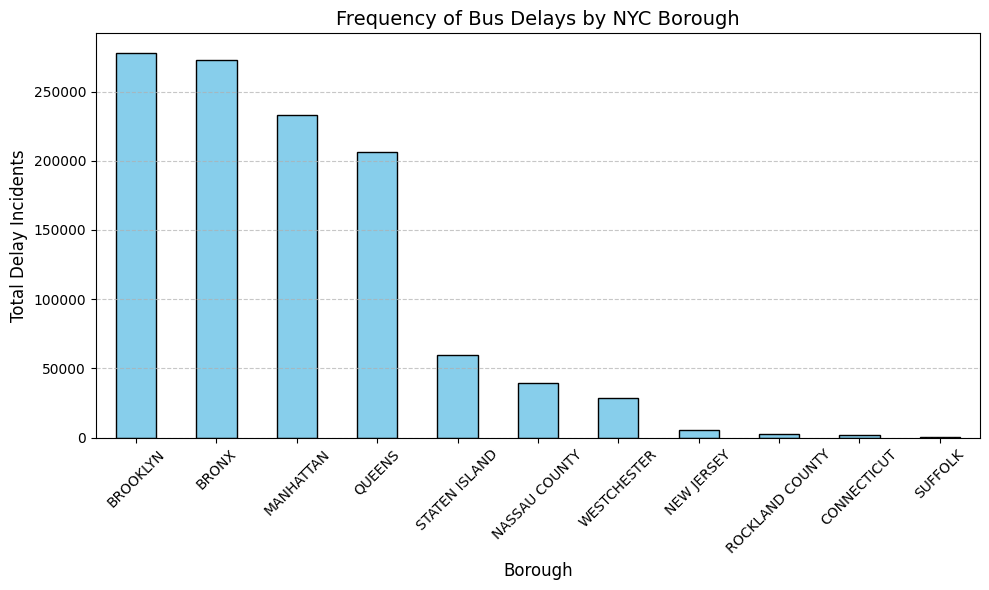

Summary of Delay Incidents by Borough:
boro
BROOKLYN           278179
BRONX              272884
MANHATTAN          233253
QUEENS             206157
STATEN ISLAND       59699
NASSAU COUNTY       39749
WESTCHESTER         28232
NEW JERSEY           5264
ROCKLAND COUNTY      2420
CONNECTICUT          2080
SUFFOLK               211
Name: count, dtype: int64


In [65]:
# 3. Visualization
plt.figure(figsize=(10, 6))
boro_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Frequency of Bus Delays by NYC Borough', fontsize=14)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Total Delay Incidents', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Output the raw numbers
print("Summary of Delay Incidents by Borough:")
print(boro_counts)

In [85]:
highest_delay_borough = boro_counts.idxmax()
highest_delay_count = boro_counts.max()
print(f"The borough with the highest number of delays is {highest_delay_borough} with {highest_delay_count} incidents.")

The borough with the highest number of delays is BROOKLYN with 278179 incidents.


In [25]:
brooklyn_delays = df[df['boro'] == 'BROOKLYN']
brooklyn_company_counts = brooklyn_delays['Bus_Company_Name'].value_counts()

print("Top bus company causing delays in Brooklyn:")
if not brooklyn_company_counts.empty:
    top_company_brooklyn = brooklyn_company_counts.idxmax()
    top_company_brooklyn_count = brooklyn_company_counts.max()
    print(f"The bus company with the most delays in Brooklyn is '{top_company_brooklyn}' with {top_company_brooklyn_count} incidents.")
else:
    print("No bus delay data found for Brooklyn.")


Top bus company causing delays in Brooklyn:
The bus company with the most delays in Brooklyn is 'BORO TRANSIT, INC.' with 28750 incidents.


In [100]:
print(brooklyn_company_counts)

Bus_Company_Name
BORO TRANSIT, INC.                28750
L & M BUS CORP.                   25820
PRIDE TRANSPORTATION (SCH AGE)    23534
EMPIRE CHARTER SERVICE INC        17759
ALLIED TRANSIT CORP.              16961
                                  ...  
L&M Bus Corp.                         1
ALL COUNTY BUS LLC (B2321)            1
first steps trans                     1
LITTLE LISA BUS CO. INC.              1
CHILDREN`S TRANS INC. (B2321)         1
Name: count, Length: 169, dtype: int64


In [96]:
brooklyn_delays = df[df['boro'] == 'BROOKLYN']
brooklyn_company_counts = brooklyn_delays['Bus_Company_Name'].value_counts()

print("Top bus company causing delays in Brooklyn:")
if not brooklyn_company_counts.empty:
    top_company_brooklyn = brooklyn_company_counts.idxmin()
    top_company_brooklyn_count = brooklyn_company_counts.min()
    print(f"The bus company with the most delays in Brooklyn is '{top_company_brooklyn}' with {top_company_brooklyn_count} incidents.")
else:
    print("No bus delay data found for Brooklyn.")

Top bus company causing delays in Brooklyn:
The bus company with the most delays in Brooklyn is 'Bobbys bus' with 1 incidents.


In [97]:
brooklyn_delays_reasons = brooklyn_delays['Reason'].value_counts()

print("Top reasons for delays in Brooklyn:")
if not brooklyn_delays_reasons.empty:
    top_reason_brooklyn = brooklyn_delays_reasons.idxmax()
    top_reason_brooklyn_count = brooklyn_delays_reasons.max()
    print(f"The most common reason for delays in Brooklyn is '{top_reason_brooklyn}' with {top_reason_brooklyn_count} incidents.")
else:
    print("No delay reasons found for Brooklyn.")


Top reasons for delays in Brooklyn:
The most common reason for delays in Brooklyn is 'Heavy Traffic' with 133641 incidents.


In [ ]:
brooklyn_delays_reasons = brooklyn_delays['Reason'].value_counts()

print("Top reasons for delays in Brooklyn:")
if not brooklyn_delays_reasons.empty:
    top_reason_brooklyn = brooklyn_delays_reasons.idxmax()
    top_reason_brooklyn_count = brooklyn_delays_reasons.max()
    print(f"The most common reason for delays in Brooklyn is '{top_reason_brooklyn}' with {top_reason_brooklyn_count} incidents.")
else:
    print("No delay reasons found for Brooklyn.")

In [28]:
brooklyn_delay_durations = brooklyn_delays['How_Long_Delayed'].value_counts()

print("Delay durations in Brooklyn:")
print(brooklyn_delay_durations)


Delay durations in Brooklyn:
How_Long_Delayed
16-30 Min     69121
31-45 Min     36611
61-90 Min     28489
46-60 Min     19340
0-15 Min       9405
              ...  
45+               1
30-40 mikn        1
35 MINS??         1
28MIN             1
\1 hr-            1
Name: count, Length: 1827, dtype: int64


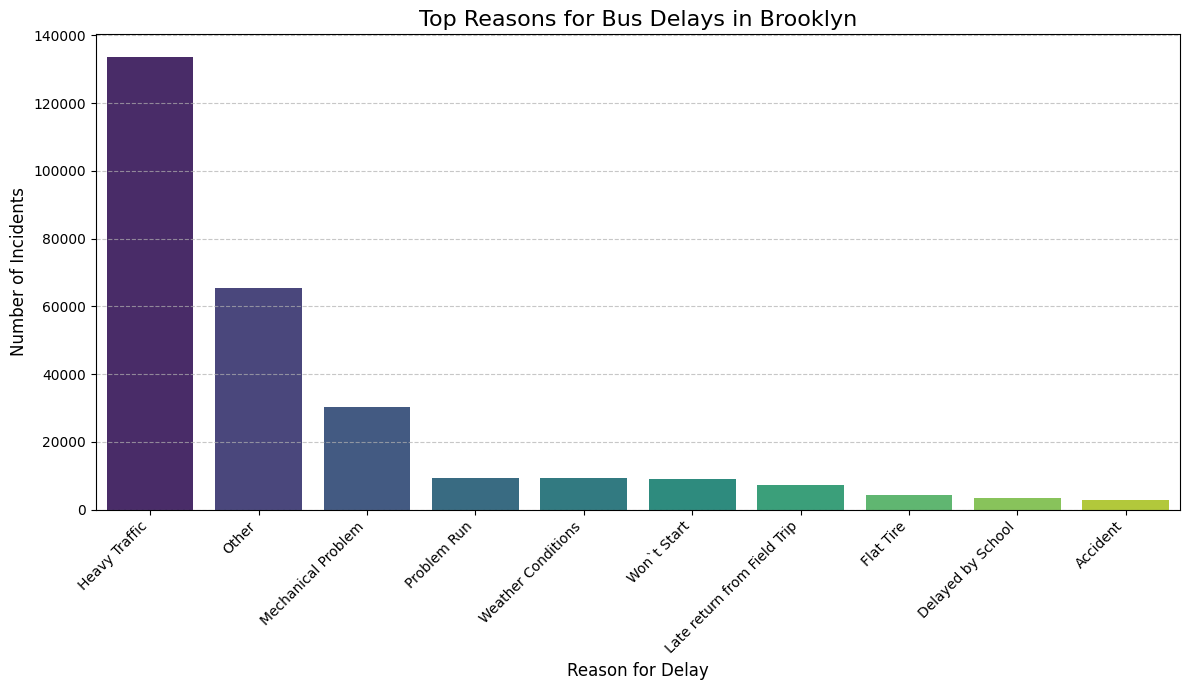

In [29]:
plt.figure(figsize=(12, 7))
sns.barplot(x=brooklyn_delays_reasons.index, y=brooklyn_delays_reasons.values, palette='viridis', hue=brooklyn_delays_reasons.index, legend=False)
plt.title('Top Reasons for Bus Delays in Brooklyn', fontsize=16)
plt.xlabel('Reason for Delay', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analyzing Delay Times in Brooklyn

In [30]:
# Convert 'Occurred_On' to datetime objects for Brooklyn delays
brooklyn_delays_time = brooklyn_delays.copy()
brooklyn_delays_time['Occurred_On'] = pd.to_datetime(brooklyn_delays_time['Occurred_On'], errors='coerce')

# Drop rows where 'Occurred_On' could not be parsed
brooklyn_delays_time.dropna(subset=['Occurred_On'], inplace=True)

# Extract hour and day of the week
brooklyn_delays_time['hour_of_day'] = brooklyn_delays_time['Occurred_On'].dt.hour
brooklyn_delays_time['day_of_week'] = brooklyn_delays_time['Occurred_On'].dt.day_name()

# Count delays by hour of day
hour_counts = brooklyn_delays_time['hour_of_day'].value_counts().sort_index()

# Count delays by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = brooklyn_delays_time['day_of_week'].value_counts().reindex(day_order)

print("Delays by Hour of Day:")
print(hour_counts)
print("\nDelays by Day of Week:")
print(day_counts)


Delays by Hour of Day:
hour_of_day
0       523
1       423
2       596
3       252
4       105
5      9728
6     90871
7     99578
8     19956
9      2957
10      857
11     1299
12     2699
13    15428
14    20993
15     8257
16     2770
17      573
18      120
19       87
20       27
21       26
22        5
23       49
Name: count, dtype: int64

Delays by Day of Week:
day_of_week
Monday       57280
Tuesday      55684
Wednesday    57876
Thursday     54330
Friday       53003
Saturday         3
Sunday           3
Name: count, dtype: int64


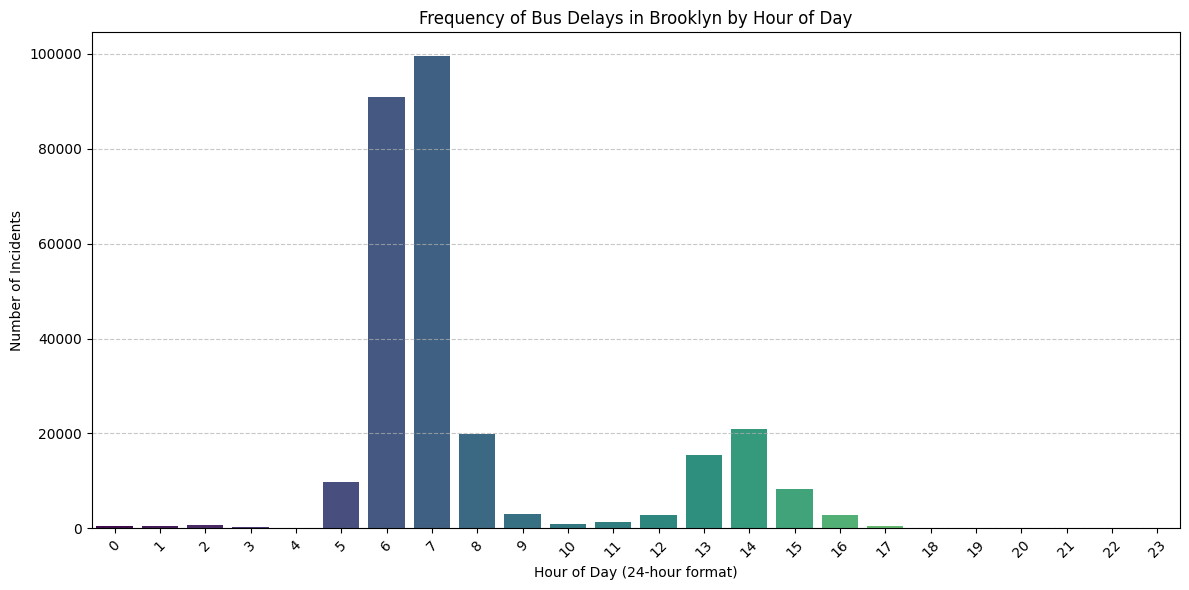

In [31]:
# Visualization: Delays by Hour of Day
plt.figure(figsize=(12, 6))
sns.barplot(x=hour_counts.index, y=hour_counts.values, palette='viridis', hue=hour_counts.index, legend=False)
plt.title('Frequency of Bus Delays in Brooklyn by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [102]:
# Find the most frequent hour and day for delays
most_common_hour = hour_counts.idxmax()
most_common_hour_count = hour_counts.max()

most_common_day = day_counts.idxmax()
most_common_day_count = day_counts.max()

print(f"The most common hour for delays in Brooklyn is {most_common_hour}:00 with {most_common_hour_count} incidents.")
print(f"The most common day for delays in Brooklyn is {most_common_day} with {most_common_day_count} incidents.")


The most common hour for delays in Brooklyn is 7:00 with 99578 incidents.
The most common day for delays in Brooklyn is Wednesday with 57876 incidents.


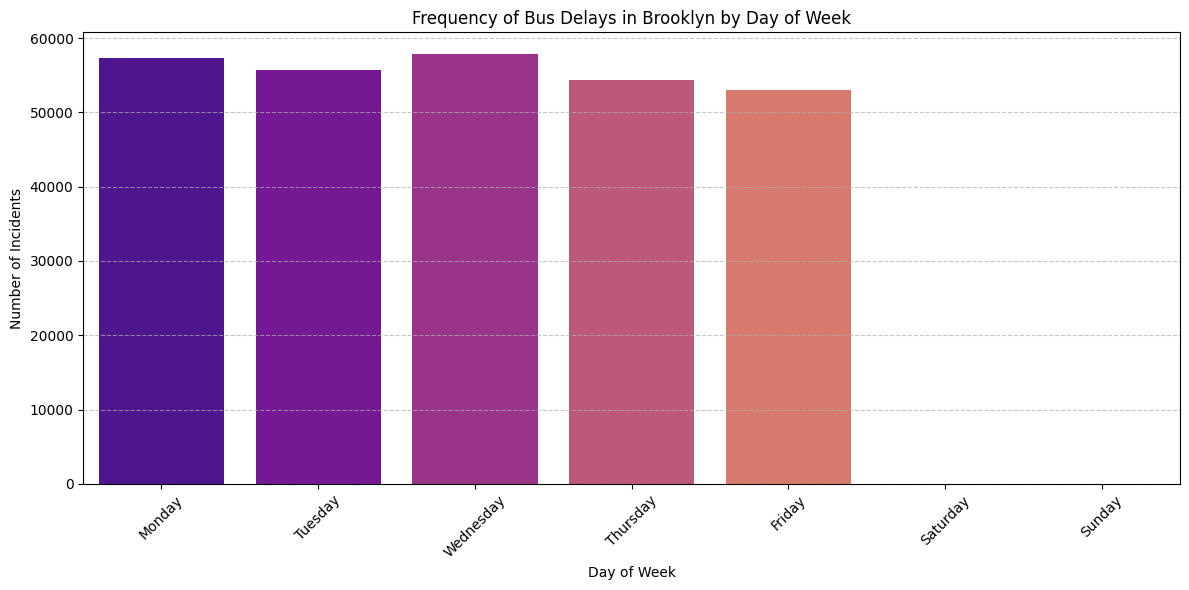

In [32]:
# Visualization: Delays by Day of Week
plt.figure(figsize=(12, 6))
sns.barplot(x=day_counts.index, y=day_counts.values, palette='plasma', hue=day_counts.index, legend=False)
plt.title('Frequency of Bus Delays in Brooklyn by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
